<a href="https://colab.research.google.com/github/DevAdedoyin/MNIST-Classification/blob/master/MNIST_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **MNIST Classisfication Task**

This is a classification task using the MNIST dataset.

The MNIST dataset is often referred to as the "hello world" of machine learning. It is a set of 70,000 images of digits handwritten by high school students of the US Census Bureau.

In [1]:
# The imports for the task goes in here

from sklearn.datasets import fetch_openml
from IPython.display import Markdown as md
import matplotlib.pyplot as plt


In [2]:
# fetch the mnist dataset and display the entire dataset

"""
    The fetch_openml() function by default returns a dataset's input as
    Pandas DataFrame and the labels as Pandas Series.
    Since the MNIST dataset is made up of images, Dataframes won't be
    ideal for it. So it's preferrable to set as_frame to False to get
    the data as a NumPy arrays instead.
"""

mnist = fetch_openml("mnist_784", as_frame=False)

In [3]:
# display the description of the dataset

md(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image by computing the center of mass of the pixels, and translating the image so as to position this point at the center of the 28x28 field.  

With some classification methods (particularly template-based methods, such as SVM and K-nearest neighbors), the error rate improves when the digits are centered by bounding box rather than center of mass. If you do this kind of pre-processing, you should report it in your publications. The MNIST database was constructed from NIST's NIST originally designated SD-3 as their training set and SD-1 as their test set. However, SD-3 is much cleaner and easier to recognize than SD-1. The reason for this can be found on the fact that SD-3 was collected among Census Bureau employees, while SD-1 was collected among high-school students. Drawing sensible conclusions from learning experiments requires that the result be independent of the choice of training set and test among the complete set of samples. Therefore it was necessary to build a new database by mixing NIST's datasets.  

The MNIST training set is composed of 30,000 patterns from SD-3 and 30,000 patterns from SD-1. Our test set was composed of 5,000 patterns from SD-3 and 5,000 patterns from SD-1. The 60,000 pattern training set contained examples from approximately 250 writers. We made sure that the sets of writers of the training set and test set were disjoint. SD-1 contains 58,527 digit images written by 500 different writers. In contrast to SD-3, where blocks of data from each writer appeared in sequence, the data in SD-1 is scrambled. Writer identities for SD-1 is available and we used this information to unscramble the writers. We then split SD-1 in two: characters written by the first 250 writers went into our new training set. The remaining 250 writers were placed in our test set. Thus we had two sets with nearly 30,000 examples each. The new training set was completed with enough examples from SD-3, starting at pattern # 0, to make a full set of 60,000 training patterns. Similarly, the new test set was completed with SD-3 examples starting at pattern # 35,000 to make a full set with 60,000 test patterns. Only a subset of 10,000 test images (5,000 from SD-1 and 5,000 from SD-3) is available on this site. The full 60,000 sample training set is available.

Downloaded from openml.org.

In [4]:
# Let's get the MNIST input data and target data

X, y = mnist.data, mnist.target

In [5]:
# display the input data

X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [6]:
# display the shape of the input data

print(f"The MNIST input data has a {X.shape} shape")

The MNIST input data has a (70000, 784) shape


In [7]:
# display the target or label data

y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [8]:
# display the shape of the target data

print(f"The MNIST target data has a {y.shape} shape")

The MNIST target data has a (70000,) shape


From the displays above, it can be seen that the MNIST dataset has 70,000 images and each images have 784 features. This is because each image is 28 x 28 pixels and each feature simply represent's one pixel's intensity from 0 (white) to 255 (black).

In [9]:
# create a function to display one of the MNIST image

def plot_digit(image_data):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")

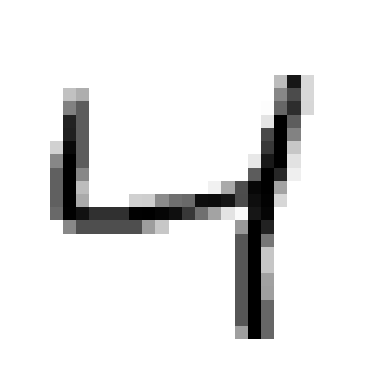

In [11]:
# display the

some_digit = X[2]
plot_digit(some_digit)
plt.show()

The image above appears to be a 4. Next let's display the label for this image to confirm it

In [12]:
# display the label for the image above

y[2]

'4'

### **Splitting into Training and Test Sets**

If you read through the description displayed earlier, you will observe that the MNIST dataset returned by the fetch_openml split into

- Training Set: 60,000 images
- Test Set: 10,000 images

The training set is already shuffled. This is very that all cross validation folds will be similar.

In [13]:
# The train and test split

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]